# Stock Market Price Prediction using Deep Learning and Sentiment Analysis

This notebook uses **two real-world Kaggle datasets**:
- Apple Stock Prices (`AAPL.csv`)
- Financial News Headlines (`Combined_News_DJIA.csv`)

It performs:
- Sentiment analysis on financial news
- Time series feature preparation
- Deep Learning prediction using LSTM
- Baseline comparison using Linear Regression
- Evaluation using RMSE, MAE, and R²
- Visualizations suitable for research papers


In [1]:
!pip install pandas numpy matplotlib scikit-learn tensorflow vaderSentiment

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import random
import tensorflow as tf

# Fix seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


## Load Stock Dataset

In [3]:
stock = pd.read_csv('AAPL.csv')
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')
stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600


## Load News Dataset

In [4]:
news = pd.read_csv('Combined_News_DJIA.csv')
news['Date'] = pd.to_datetime(news['Date'])
news.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Elephants extinct by 2020?',b'US humanitarian missions soon in Georgia - i...,"b""Georgia's DDOS came from US sources""","b'Russian convoy heads into Georgia, violating...",b'Israeli defence minister: US against strike ...,b'Gorbachev: We Had No Choice',b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree 

## Sentiment Analysis using VADER

In [5]:
analyzer = SentimentIntensityAnalyzer()

def compute_sentiment(row):
    text = ' '.join([str(row[i]) for i in row.index if 'Top' in i])
    score = analyzer.polarity_scores(text)
    return score['compound']

news['Sentiment'] = news.apply(compute_sentiment, axis=1)
news = news[['Date','Sentiment']]
news.head()

,Date,Sentiment
0,2008-08-08,-0.9979
1,2008-08-11,-0.9804
2,2008-08-12,-0.9658
3,2008-08-13,-0.9809
4,2008-08-14,-0.9802


## Merge Stock and Sentiment Data

In [6]:
data = pd.merge(stock, news, on='Date', how='inner')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Sentiment
0,2008-08-08,5.852143,6.058929,5.848214,6.055357,5.177438,713997200,-0.9979
1,2008-08-11,6.073929,6.303571,6.059643,6.198571,5.299890,891304400,-0.9804
2,2008-08-12,6.197143,6.403214,6.196786,6.311786,5.396692,836278800,-0.9658
3,2008-08-13,6.356429,6.428571,6.282143,6.403571,5.475169,842346400,-0.9809
4,2008-08-14,6.368929,6.444643,6.351429,6.404286,5.475780,711300800,-0.9802


## Visualization: Stock Price Trend

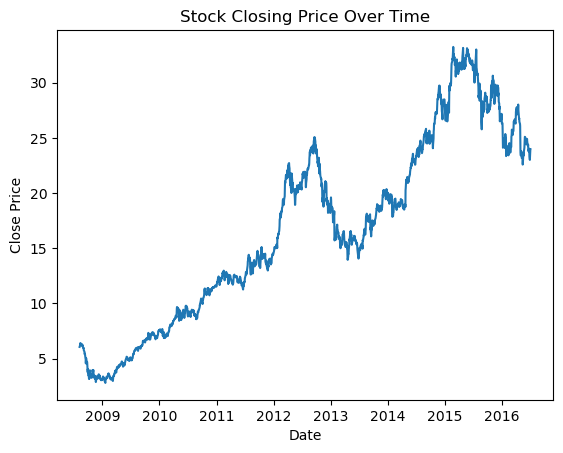

In [7]:
plt.figure()
plt.plot(data['Date'], data['Close'])
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

## Visualization: News Sentiment Trend

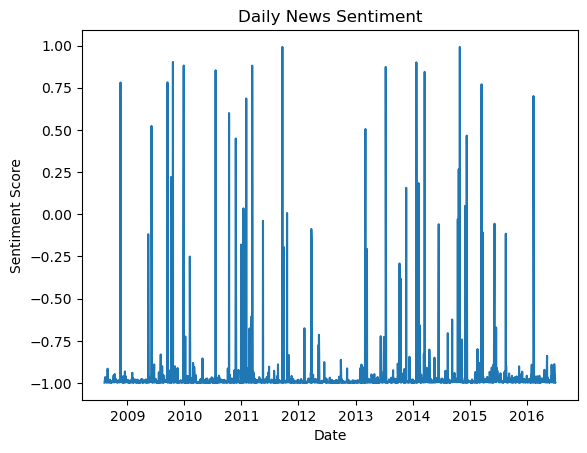

In [8]:
plt.figure()
plt.plot(data['Date'], data['Sentiment'])
plt.title('Daily News Sentiment')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.show()

## Feature Selection

In [9]:
features = ['Open','High','Low','Close','Volume','Sentiment']

dataset = data[features].values

scaler = MinMaxScaler()
dataset_scaled = scaler.fit_transform(dataset)


## Create Time Series Sequences

In [10]:
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step)])
        y.append(data[i+time_step][3])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(dataset_scaled, time_step)


## Train Test Split

In [11]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


## Deep Learning Model: LSTM

In [12]:
model = Sequential()
model.add(LSTM(50, input_shape=(time_step, X.shape[2])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\28rac\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          11,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,451 (44.73 KB)

 Trainable params: 11,451 (44.73 KB)

 Non-trainable params: 0 (0.00 B)

## Train LSTM Model

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    shuffle=False
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0017
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8289e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0322e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5611e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8523e-04
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6975e-04
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6795e-04
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7035e-04
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7609e-04
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8473e-04
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9524e-04
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0567e-04
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s

## LSTM Training Loss Visualization

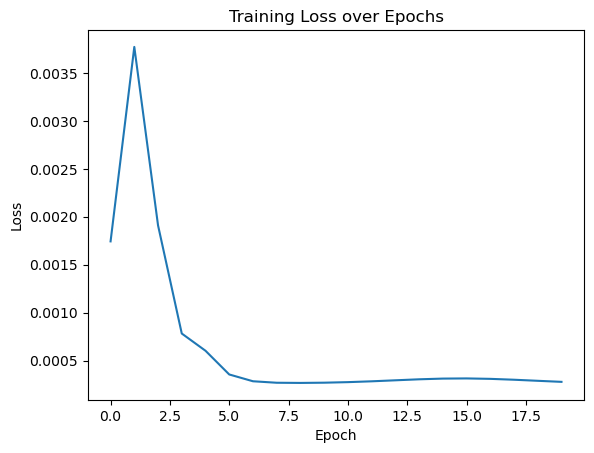

In [14]:
plt.figure()
plt.plot(history.history['loss'])
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## LSTM Predictions

In [15]:
predictions_lstm = model.predict(X_test)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


## LSTM Evaluation Metrics

In [16]:
rmse_lstm = np.sqrt(mean_squared_error(y_test, predictions_lstm))
mae_lstm = mean_absolute_error(y_test, predictions_lstm)
r2_lstm = r2_score(y_test, predictions_lstm)

print('LSTM RMSE:', rmse_lstm)
print('LSTM MAE:', mae_lstm)
print('LSTM R2:', r2_lstm)


LSTM RMSE: 0.022126034850336814
LSTM MAE: 0.017299831823972833
LSTM R2: 0.9465059745829629


## Baseline Model: Linear Regression

In [17]:
# Flatten sequence data for Linear Regression
X_train_lr = X_train.reshape(X_train.shape[0], -1)
X_test_lr = X_test.reshape(X_test.shape[0], -1)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

predictions_lr = lr_model.predict(X_test_lr)


## Linear Regression Evaluation

In [18]:
rmse_lr = np.sqrt(mean_squared_error(y_test, predictions_lr))
mae_lr = mean_absolute_error(y_test, predictions_lr)
r2_lr = r2_score(y_test, predictions_lr)

print('Linear Regression RMSE:', rmse_lr)
print('Linear Regression MAE:', mae_lr)
print('Linear Regression R2:', r2_lr)


Linear Regression RMSE: 0.01596453395268906
Linear Regression MAE: 0.01195533156460132
Linear Regression R2: 0.9721509371561028


## Actual vs Predicted (LSTM)

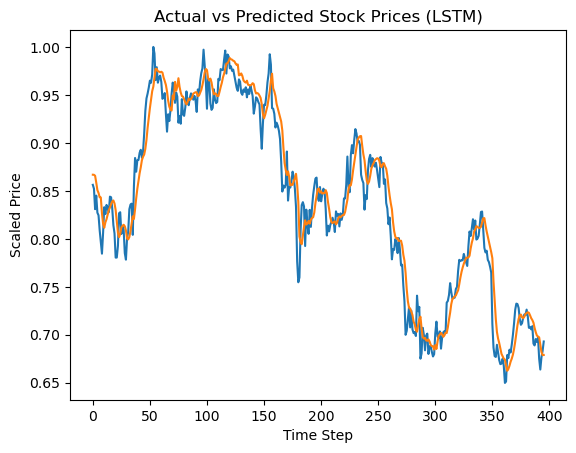

In [19]:
plt.figure()
plt.plot(y_test)
plt.plot(predictions_lstm)
plt.title('Actual vs Predicted Stock Prices (LSTM)')
plt.xlabel('Time Step')
plt.ylabel('Scaled Price')
plt.show()

In [20]:
model.save("lstm_model.h5")